# Linear Regression 

Input chính:

```text
../processed_data/model_ready/gdsc2_lgbm_style_data.npz
```

File `.npz` chứa sẵn:

```text
X_train, y_train, X_val, y_val, X_test, y_test
```


In [7]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)

## 1. Load processed data



In [8]:
DATA_PATH = Path('../processed_data/model_ready/gdsc2_lgbm_style_data.npz')
METADATA_PATH = Path('../processed_data/model_ready/artifacts/gdsc2_lgbm_style_metadata.json')
OUTPUT_DIR = Path('../models/linear_regression_processed_data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

loaded = np.load(DATA_PATH)
X_train = loaded['X_train']
y_train = loaded['y_train']
X_val = loaded['X_val']
y_val = loaded['y_val']
X_test = loaded['X_test']
y_test = loaded['y_test']

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

print('Loaded processed data')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)
metadata

Loaded processed data
X_train: (65239, 1477) y_train: (65239,)
X_val:   (9233, 1477) y_val:   (9233,)
X_test:  (18231, 1477) y_test:  (18231,)


{'dataset': 'GDSC2',
 'split_method': 'cold_split by Cell Line_ID',
 'random_state': 42,
 'drug_feature': 'Morgan fingerprint 1024 bits',
 'cell_feature': 'StandardScaler + PCA fitted on train cell lines only',
 'cell_pca_components': 453,
 'X_train_shape': [65239, 1477],
 'X_val_shape': [9233, 1477],
 'X_test_shape': [18231, 1477],
 'saved_npz': '../processed_data/model_ready/gdsc2_lgbm_style_data.npz'}

## 2. Evaluation helpers



In [9]:
def compute_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'pearson': float(pearsonr(y_true, y_pred)[0]),
        'spearman': float(spearmanr(y_true, y_pred)[0]),
    }


def train_eval_sklearn_model(model_name, model):
    start = time.time()
    model.fit(X_train, y_train)
    fit_seconds = time.time() - start

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    result = {
        'model': model_name,
        'fit_seconds': fit_seconds,
        'val': compute_metrics(y_val, val_pred),
        'test': compute_metrics(y_test, test_pred),
    }

    joblib.dump(model, OUTPUT_DIR / f'{model_name}.joblib')
    np.save(OUTPUT_DIR / f'{model_name}_val_pred.npy', val_pred)
    np.save(OUTPUT_DIR / f'{model_name}_test_pred.npy', test_pred)

    return result, val_pred, test_pred

## 3. Train Linear Regression baseline



In [10]:
final_model = LinearRegression()
final_model.fit(X_train, y_train)

val_pred = final_model.predict(X_val)
test_pred = final_model.predict(X_test)

result = compute_metrics(y_val, val_pred)
print('Validation Metrics:\n')
for metric, value in result.items():
    print(f'{metric}: {value:.4f}')
print('\n')
result = compute_metrics(y_test, test_pred)
print('Test Metrics:\n')
for metric, value in result.items():
    print(f'{metric}: {value:.4f}')

Validation Metrics:

rmse: 1.3797
mae: 1.0529
r2: 0.7333
pearson: 0.8585
spearman: 0.8043


Test Metrics:

rmse: 1.4255
mae: 1.0854
r2: 0.7252
pearson: 0.8518
spearman: 0.7934


## 4. Learning Curve

Learning curve giúp kiểm tra model đang bị underfit hay overfit. Ta train Linear Regression với nhiều kích thước tập train khác nhau, rồi so sánh lỗi trên train và validation.


,train_fraction,train_size,fit_seconds,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_pearson,val_pearson
0,0.1,6523,0.4386,1.1401,1.3414,0.8604,1.0115,0.8217,0.7479,0.9065,0.8657
1,0.2,13047,0.6613,1.1643,1.3149,0.8763,0.9946,0.8172,0.7578,0.9040,0.8723
2,0.4,26095,1.1598,1.1806,1.3239,0.8836,1.0026,0.8122,0.7545,0.9012,0.8709
3,0.6,39143,1.6421,1.2010,1.3324,0.8951,1.0042,0.8059,0.7513,0.8977,0.8687
4,0.8,52191,2.0581,1.2116,1.3335,0.9026,1.0067,0.8027,0.7509,0.8959,0.8686
5,1.0,65239,2.5571,1.2660,1.3797,0.9538,1.0530,0.7845,0.7333,0.8857,0.8585


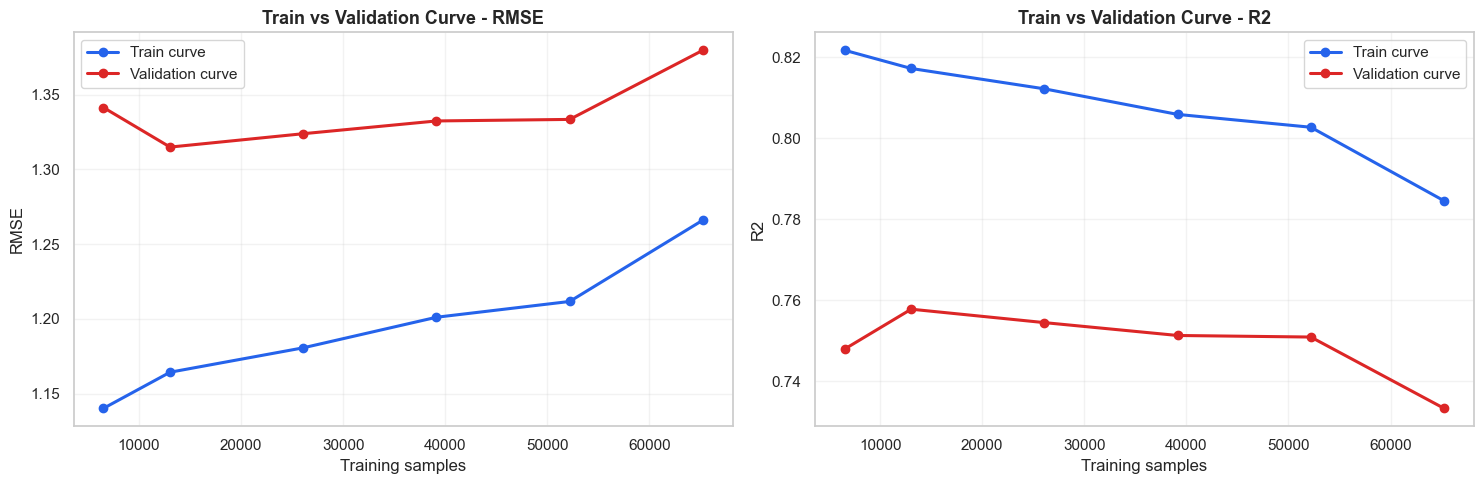

In [11]:
from sklearn.base import clone

def run_learning_curve(base_model, train_fractions, random_state=42):
    rng = np.random.default_rng(random_state)
    n_train = len(X_train)
    rows = []

    for fraction in train_fractions:
        sample_size = max(10, int(n_train * fraction))
        sample_idx = rng.choice(n_train, size=sample_size, replace=False)

        model = clone(base_model)
        start = time.time()
        model.fit(X_train[sample_idx], y_train[sample_idx])
        fit_seconds = time.time() - start

        train_pred = model.predict(X_train[sample_idx])
        val_pred = model.predict(X_val)

        train_metrics = compute_metrics(y_train[sample_idx], train_pred)
        val_metrics = compute_metrics(y_val, val_pred)

        rows.append({
            'train_fraction': fraction,
            'train_size': sample_size,
            'fit_seconds': fit_seconds,
            'train_rmse': train_metrics['rmse'],
            'val_rmse': val_metrics['rmse'],
            'train_mae': train_metrics['mae'],
            'val_mae': val_metrics['mae'],
            'train_r2': train_metrics['r2'],
            'val_r2': val_metrics['r2'],
            'train_pearson': train_metrics['pearson'],
            'val_pearson': val_metrics['pearson'],
        })

    return pd.DataFrame(rows)


train_fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
learning_curve_df = run_learning_curve(LinearRegression(), train_fractions)
display(learning_curve_df.round(4))
learning_curve_df.to_csv(OUTPUT_DIR / 'linear_regression_learning_curve.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

axes[0].plot(
    learning_curve_df['train_size'],
    learning_curve_df['train_rmse'],
    marker='o',
    linewidth=2.2,
    color='#2563eb',
    label='Train curve',
)
axes[0].plot(
    learning_curve_df['train_size'],
    learning_curve_df['val_rmse'],
    marker='o',
    linewidth=2.2,
    color='#dc2626',
    label='Validation curve',
)
axes[0].set_title('Train vs Validation Curve - RMSE', fontsize=13, weight='bold')
axes[0].set_xlabel('Training samples')
axes[0].set_ylabel('RMSE')
axes[0].legend(title=None)

axes[1].plot(
    learning_curve_df['train_size'],
    learning_curve_df['train_r2'],
    marker='o',
    linewidth=2.2,
    color='#2563eb',
    label='Train curve',
)
axes[1].plot(
    learning_curve_df['train_size'],
    learning_curve_df['val_r2'],
    marker='o',
    linewidth=2.2,
    color='#dc2626',
    label='Validation curve',
)
axes[1].set_title('Train vs Validation Curve - R2', fontsize=13, weight='bold')
axes[1].set_xlabel('Training samples')
axes[1].set_ylabel('R2')
axes[1].legend(title=None)

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'linear_regression_train_validation_curves.png', dpi=160, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'linear_regression_learning_curve.png', dpi=160, bbox_inches='tight')
plt.show()
